# HITO 3 – 
## Reconocimiento y Clasificación de Tumores Cerebrales – Desarrollo e Integración de Servicios de IA

## 1. Carga de los datos

En el Hito 2 se realizó la organización del conjunto de datos del que disponemos en 3 carpetas: train, conjunto de entrenamiento; val, conjunto de validación; y test, conjunto de prueba. En este Hito solo será necesario cargar los datos guardados en dichas carpetas.

In [1]:
from pathlib import Path
from tensorflow import keras
import os
import pandas as pd
random_state = 42
batch_size = 32  
image_size = (256,256)
directory = Path(".") / "data"/ "train"  # Directorio donde se ubican los datos
# Genera los datasets de train, validación y test a partir de las imágenes de los directorios
ds_train = keras.utils.image_dataset_from_directory(directory, batch_size = batch_size, image_size = image_size, seed = random_state)
directory = Path(".") / "data" / "val"
ds_validation = keras.utils.image_dataset_from_directory(directory, batch_size = batch_size, image_size = image_size, seed = random_state)
directory = Path(".") / "data" / "test"
ds_test = keras.utils.image_dataset_from_directory(directory, batch_size = batch_size, image_size = image_size, shuffle = False)

Found 1855 files belonging to 4 classes.
Found 617 files belonging to 4 classes.
Found 624 files belonging to 4 classes.


Asimismo, volvemos a definir el ajuste de pesos realizado para solventar el desbalanceo de clases, ya que la clase 'normal' consta de menos instancias.

meningioma_tumor
glioma_tumor
pituitary_tumor
normal
Pesos para cada clase:
------------------------------------
{'meningioma_tumor': 0.19298399393371107, 'glioma_tumor': 0.19548563829951845, 'pituitary_tumor': 0.20862103692043474, 'normal': 0.40290933084633573}
------------------------------------
Frecuencia de aparición de cada clase:


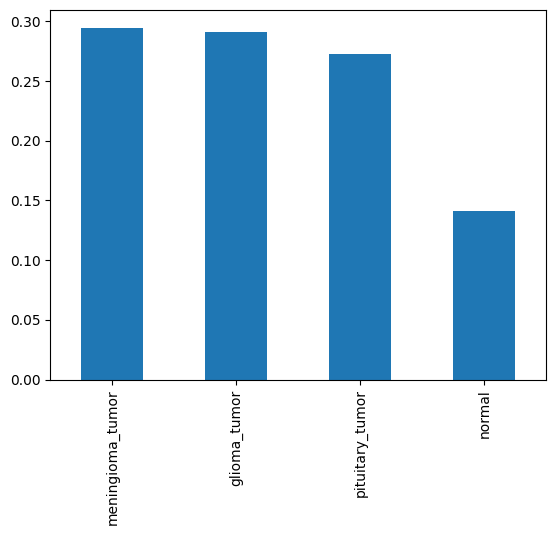

In [2]:
function = lambda file: file.split(os.sep)[2]
iterable = ds_train.file_paths
generator = map(function, iterable)

data = list(generator)  
normalize = True  
sort = True  
kind = "bar"  
frecuencias = pd.Series(data).value_counts(normalize, sort)
#print(frecuencias)
weights = {}
cont = 0
total = 0
for clase,frec in frecuencias.items():
    valor = 1/frec
    weights[clase]= valor
    total += valor
    cont+=1
#print(weights)
#normalizamos pesos
class_weights = {}
cont = 0
for clase,w in weights.items():
    print(clase)
    class_weights[clase] = w/total
    cont+=1
class_indices = {clase: idx for idx, clase in enumerate(frecuencias.keys())}
mapped_class_weights = {class_indices[clase]: peso for clase, peso in class_weights.items()}
print("Pesos para cada clase:")
print("------------------------------------")
print(class_weights)
print("------------------------------------")
print("Frecuencia de aparición de cada clase:")
pd.Series(data).value_counts(normalize, sort).plot(kind = kind);

## 2. Aumentación de datos

Como se definió en el Hito anterior, es necesario introducir aumentación de datos debido a que disponemos de un conjunto de datos reducido. Asimismo, esto proporciona otra medida contra el sobreajuste, ya que, a más datos, más difícil es que el modelo sobreajuste.

In [3]:
from keras import Sequential
from keras import layers
import matplotlib.pyplot as plt
import numpy as np
data_augmentation = Sequential(
    [
        layers.RandomRotation(
        0.1, 
        fill_mode='constant', 
        fill_value=0.0       
        ),
        layers.RandomZoom(
            0.2, 
            fill_mode='constant', # esto hace que las zonas no ampliadas de la imagen se rellenen de color negro
            fill_value=0.0
        )
    ]
)

## 3. Modelos

Los modelos seleccionados para realizar la clasificación del conjunto de datos son redes neuronales convolucionales, a excepción del modelo baseline. Este modelo baseline se utilizará como la línea de partida que nuestros modelos deben superar para considerarse adecuado para la resolución del problema. El modelo que se va a utilizar como baseline es un Perceptrón Multicapa (MLP), que actua como un clasificador dummy, ya que no usa convoluciones que extráigan las características principales de los datos.

Los modelos de CNN se han seleccionado debido a varias razones:
- **Reconocimiento de patrones**: Las CNN descifran las características de la imagen, como bordes o texturas, independientemente de dónde se encuentren esos patrones dentro de la imagen. Esto lo logran mediante los filtros de convolución. Esta propiedad de las CNN es vital en nuestro problema, pues commo se pudo ver en el Hito 2, las imágenes se componen de texturas, bordes y contrastes característicos para cada imagen.
- **Reconocimiento incremental**: Cuantas más capas de convolución se utilicen, la red será capaz de reconocer patrones y formas más complejos.

En este apartado se definen varios modelos  para observar cómo se comportan 2 redes neuronales de 2 familias distintas: una red neuronal convolucional hecha a mano y una red neuronal pre-entrenada (Transfer Learning).

### 3.1 Baseline

In [4]:
from tensorflow.keras import layers, models

model_dummy = models.Sequential([
    layers.Input(shape=(256, 256, 3)),
    layers.Rescaling(1./255),
    layers.Flatten(),
    layers.Dense(4, activation='softmax')
])

model_dummy.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_dummy.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 196608)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │       786,436 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 786,436 (3.00 MB)

 Trainable params: 786,436 (3.00 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
history_dummy = model_dummy.fit(
    ds_train,
    validation_data=ds_validation,
    epochs=30
)

Epoch 1/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.8841 - loss: 0.6085 - val_accuracy: 0.7180 - val_loss: 2.8667
Epoch 2/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9569 - loss: 0.1718 - val_accuracy: 0.6807 - val_loss: 3.5270
Epoch 3/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9348 - loss: 0.2222 - val_accuracy: 0.7131 - val_loss: 3.0278
Epoch 4/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9720 - loss: 0.0770 - val_accuracy: 0.7131 - val_loss: 2.9384
Epoch 5/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9639 - loss: 0.1187 - val_accuracy: 0.6807 - val_loss: 3.2941
Epoch 6/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9633 - loss: 0.1114 - val_accuracy: 0.7326 - val_loss: 2.9796
Epoch 7/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9456 - loss: 0.2295 - val_accuracy: 0.7115 - val_loss: 3.5859
Epoch 8/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9159 - loss: 0.3750 - val_accuracy: 0.6888 - v

In [11]:
def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    plt.style.use('ggplot')
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    # Gráfica de Accuracy
    ax1.plot(epochs, acc, 'b', label='Entrenamiento')
    ax1.plot(epochs, val_acc, 'r', label='Validación')
    ax1.set_title('Precisión (Accuracy)')
    ax1.set_xlabel('Épocas')
    ax1.set_ylabel('Accuracy')
    ax1.legend()

    # Gráfica de Loss
    ax2.plot(epochs, loss, 'b', label='Entrenamiento')
    ax2.plot(epochs, val_loss, 'r', label='Validación')
    ax2.set_title('Pérdida (Loss)')
    ax2.set_xlabel('Épocas')
    ax2.set_ylabel('Loss')
    ax2.legend()

    plt.tight_layout()
    plt.show()

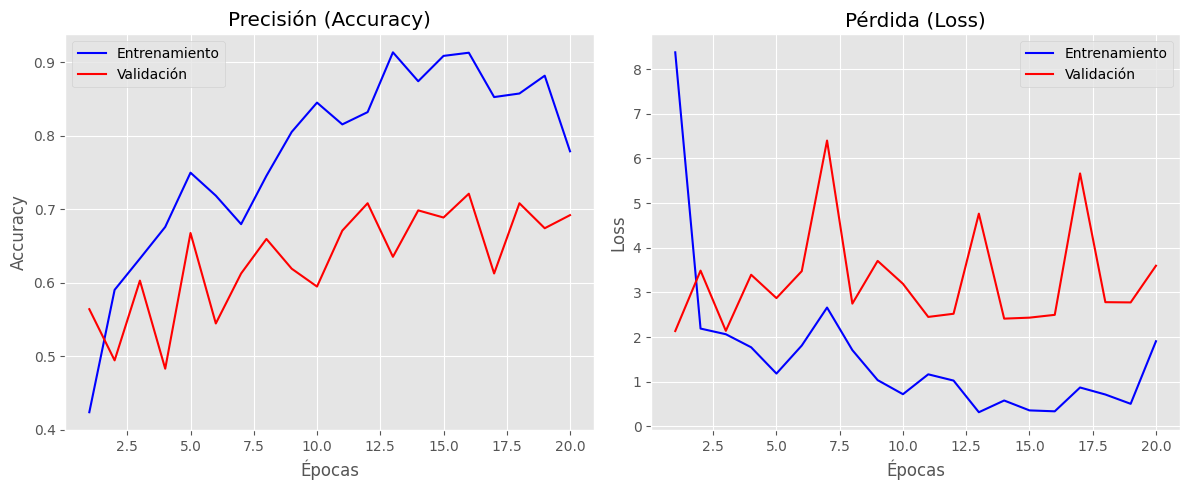

In [7]:
plot_history(history_dummy)

Como se puede apreciar en las gráficas, el modelo sobreajusta mucho. Esto se debe a que no es capaz de extrer las características de las imágenes y memoriza el conjunto.

In [12]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

y_true = np.concatenate([y for x, y in ds_test], axis=0)
y_pred_probs = model_dummy.predict(ds_test)
y_pred = np.argmax(y_pred_probs, axis=1)
class_names = ds_test.class_names
print(classification_report(y_true, y_pred, target_names=class_names))

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
                  precision    recall  f1-score   support

    glioma_tumor       0.68      0.61      0.64       181
meningioma_tumor       0.58      0.66      0.62       184
          normal       0.75      0.72      0.74        89
 pituitary_tumor       0.84      0.82      0.83       170

        accuracy                           0.70       624
       macro avg       0.71      0.70      0.71       624
    weighted avg       0.70      0.70      0.70       624



### 3.2 CNN custom 

Se establecen los callbacks para poder guardar el mejor modelo entrenado, así comom los datos de entrenamiento para su posterior análisis en gráficos.

In [97]:
import tensorflow as tf
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath="convnet_from_scratch.keras",
        save_best_only=True,
        monitor="val_loss"),
        tf.keras.callbacks.CSVLogger("training_log_cnn_custom.csv", append=True)
]

El primer modelo será la CNN custom. A esta red añadiremos aumentación de datos y una técnica específica para combatir el sobreajuste.
Capas básicas de la red convolucional:
- `Input:` **Define el tamaño** de los datos de entrada, que en este caso serán imágenes de 256 x 256 píxeles.
- `Rescaling:` **Normaliza** los datos de entrada a la red convolucional, para que pueda trabajar con valores entre 0 y 1, en lugar de 0 y 255.
- `Conv2D:` Es la **capa fundamental** para las CNN de clasificación de imágenes, ya que es la que se encarga de detectar los patrones de las imágenes, como bordes, formas o texturas, aplicando los kernels (filtros). Además, en este ejemplo usamos la función de activación **relu**, que actua con eficiencia y rapidez para el aprendizaje. También iremos aumentando el número de filtros que les pasamos a las imágenes para que se detecten más patrones progresivamente.
- `MaxPooling2D:` Nos quedamos con las **propiedades más características** de las imágenes para poder mejorar el rendimiento de la red.
- `Flatten:` Se utiliza para **aplanar** la salida de las capas de la red que no trabajan con vectores, como las convolucionales, y poder usarla como entrada de una capa densa, que si que trabaja con vectores.
- `Dense:` Nos dará la **clasificación de las imágenes** que le hemos pasado al modelo. Es importante que las unidades de esta capa coincidan con el número de clases que tenemos, en este caso, 4. Asimismo, usamos la función de activación softmax, ya que estamos en un problema de clasificación multiclase.

Aumentación de datos y sobreajuste:
- `Aumentación de datos:` Esta técnica se considera debido a lo establecido en el punto 2.
- `Técnica para combatir el sobreajuste:`  Se ha introducido una capa de **Dropout**, que consiste en apagar una fracción de las neuronas usadas en el entrenamiento aleatoriamente. Esto hace que se cree un modelo más general y robusto.

In [ ]:
length = 79
model = Sequential([
    layers.Input(shape=(256, 256, 3)),
    data_augmentation, #aplicamos la aumentación de datos
    layers.Rescaling(1./255),
    layers.Conv2D(filters=32, kernel_size=3, activation="relu"),
    layers.MaxPooling2D(pool_size=2),
    layers.Conv2D(filters=64, kernel_size=3, activation="relu"),
    layers.MaxPooling2D(pool_size=2),
    layers.Conv2D(filters=128, kernel_size=3, activation="relu"),
    layers.MaxPooling2D(pool_size=2),
    layers.Conv2D(filters=256, kernel_size=3, activation="relu"),
    layers.MaxPooling2D(pool_size=2),
    layers.Conv2D(filters=256, kernel_size=3, activation="relu"),
    layers.Flatten(),
    layers.Dropout(0.5), #aplicamos dropout
    layers.Dense(4, activation="softmax")
])
model.summary(length)

Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                     ┃ Output Shape             ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_14 (Sequential)       │ (None, 256, 256, 3)      │             0 │
├──────────────────────────────────┼──────────────────────────┼───────────────┤
│ rescaling_7 (Rescaling)          │ (None, 256, 256, 3)      │             0 │
├──────────────────────────────────┼──────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)               │ (None, 254, 254, 32)     │           896 │
├──────────────────────────────────┼──────────────────────────┼───────────────┤
│ max_pooling2d_28 (MaxPooling2D)  │ (None, 127, 127, 32)     │             0 │
├──────────────────────────────────┼──────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)               │ (None, 125, 125, 64)     │        18,496 │
├──────────────────────────────────┼──────────────────────────┼───────────────┤
│ max_pooling2d_29 (MaxPooling2D)  │ (None, 62, 62, 64)       │             0 │
├──────────────────────────────────┼──────────────────────────┼───────────────┤
│ conv2d_36 (Conv2D)               │ (None, 60, 60, 128)      │        73,856 │
├──────────────────────────────────┼──────────────────────────┼───────────────┤
│ max_pooling2d_30 (MaxPooling2D)  │ (None, 30, 30, 128)      │             0 │
├──────────────────────────────────┼──────────────────────────┼───────────────┤
│ conv2d_37 (Conv2D)               │ (None, 28, 28, 256)      │       295,168 │
├──────────────────────────────────┼──────────────────────────┼───────────────┤
│ max_pooling2d_31 (MaxPooling2D)  │ (None, 14, 14, 256)      │             0 │
├──────────────────────────────────┼──────────────────────────┼───────────────┤
│ conv2d_38 (Conv2D)               │ (None, 12, 12, 256)      │       590,080 │
├──────────────────────────────────┼──────────────────────────┼───────────────┤
│ flatten_7 (Flatten)              │ (None, 36864)            │             0 │
├──────────────────────────────────┼──────────────────────────┼───────────────┤
│ dropout_7 (Dropout)              │ (None, 36864)            │             0 │
├──────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense_7 (Dense)                  │ (None, 4)                │       147,460 │
└──────────────────────────────────┴──────────────────────────┴───────────────┘

 Total params: 1,125,956 (4.30 MB)

 Trainable params: 1,125,956 (4.30 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import matplotlib.pyplot as plt

# Función utilizada para mostrar los datos de accuracy y loss por época
def plot_history_from_csv(csv_path):
    if not os.path.exists(csv_path):
        print("No hay historial guardado todavía.")
        return

    df = pd.read_csv(csv_path)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Gráfica de Accuracy
    df[['accuracy', 'val_accuracy']].plot(ax=ax1, marker='o')
    ax1.set_title('Precisión del Modelo')
    ax1.set_ylabel('Accuracy')
    ax1.set_xlabel('Época')
    ax1.grid(True)

    # Gráfica de Loss
    df[['loss', 'val_loss']].plot(ax=ax2, marker='o')
    ax2.set_title('Pérdida del Modelo')
    ax2.set_ylabel('Loss')
    ax2.set_xlabel('Época')
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

Se ha establecido utilizar el optimizador Adam, debido a que es uno de los optimizadores más utilizados y que mejor funcionan. Este algoritmo ajusta la tasa de aprendizaje para cada parámetro individualmente, lo que mejora la eficiencia, la convergencia y la gestión de gradientes dispersos. 

Se ha utilizado un learning rate para Adam de 0.001 pues suele ser el la tasa estándar y más recomendada.

In [100]:
lr = 0.001
optimizer = tf.keras.optimizers.Adam(lr)

model.compile(optimizer=optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"])

In [ ]:
from tensorflow.keras.models import load_model
ruta = "./convnet.keras"
if os.path.exists(ruta):
    print("El modelo entrenado ya existe. Modelo cargado")
    model.load_weights(ruta)
    for x, y in ds_test.take(1):
        _ = model.predict(x, verbose=0)
else:
    history = model.fit(
        x = ds_train,
        epochs=100,
        validation_data= ds_validation,
        callbacks=callbacks,
        class_weight=mapped_class_weights)
    model.save("convnet.keras")

Epoch 1/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 26s 420ms/step - accuracy: 0.2722 - loss: 0.3317 - val_accuracy: 0.2723 - val_loss: 1.3884
Epoch 2/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 24s 413ms/step - accuracy: 0.3229 - loss: 0.3016 - val_accuracy: 0.3404 - val_loss: 1.8687
Epoch 3/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 65s 1s/step - accuracy: 0.4765 - loss: 0.2622 - val_accuracy: 0.4700 - val_loss: 1.3502
Epoch 4/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 90s 2s/step - accuracy: 0.5725 - loss: 0.2270 - val_accuracy: 0.5575 - val_loss: 1.0566
Epoch 5/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 143s 2s/step - accuracy: 0.6049 - loss: 0.2003 - val_accuracy: 0.7066 - val_loss: 0.7430
Epoch 6/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 39s 647ms/step - accuracy: 0.6000 - loss: 0.2141 - val_accuracy: 0.6110 - val_loss: 1.1271
Epoch 7/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 24s 420ms/step - accuracy: 0.6226 - loss: 0.2080 - val_accuracy: 0.6013 - val_loss: 0.9355
Epoch 8/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 26s 441ms/step - accuracy: 0.6631 - loss: 0.1774 - val_accu

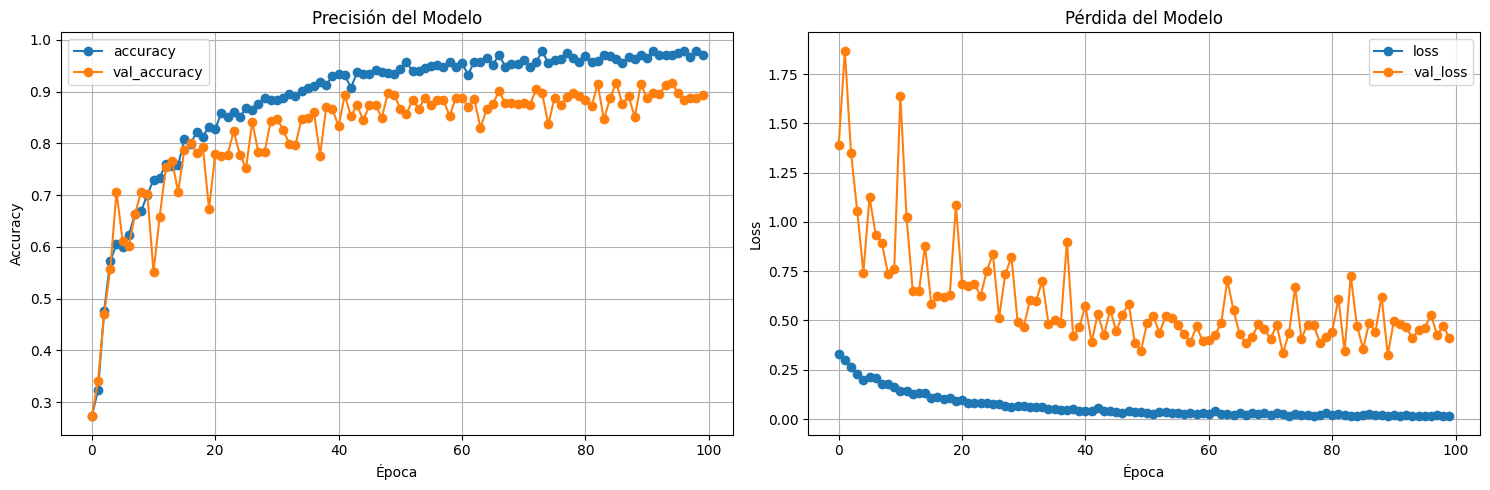

In [111]:
ruta = './training_log_cnn_custom.csv'
if os.path.exists(ruta):
    plot_history_from_csv(ruta)
else:
    print("No se ha guardado historial de datos")

Como se puede apreciar en el gráfico, el modelo tiende a sobreajustar a partir de la época 40.

In [102]:
class_names = ds_train.class_names
def predict_and_show_top_3(img_path):
    img = keras.utils.load_img(img_path, target_size=(256, 256))
    img_array = keras.utils.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) # Crear batch de 1

    preds = model.predict(img_array)[0]
    top_3_indices = np.argsort(preds)[-3:][::-1]

    print(f"\nResultados para: {os.path.basename(img_path)}")
    for i in top_3_indices:
        print(f"  - {class_names[i]}: {preds[i]*100:.2f}%")
    
    return img_array

In [ ]:
y_true = np.concatenate([y for x, y in ds_test], axis=0)
y_pred_probs = model.predict(ds_test)
y_pred = np.argmax(y_pred_probs, axis=1)

print(classification_report(y_true, y_pred, target_names=class_names))

20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 97ms/step
                  precision    recall  f1-score   support

    glioma_tumor       0.96      0.78      0.86       181
meningioma_tumor       0.84      0.88      0.86       184
          normal       0.88      0.92      0.90        89
 pituitary_tumor       0.87      0.98      0.92       170

        accuracy                           0.88       624
       macro avg       0.89      0.89      0.89       624
    weighted avg       0.89      0.88      0.88       624



Para mostrar el reporte de clasificación, se utiliza el mejor modelo adquirido durante el entrenamiento, como se ha mencionado en la parte de los callbacks. Se pueden apreciar diversos matices:
- ``Clase glioma_tumor``: Presenta la **precisión** más alta para todas las clases. Esto quiere decir que cuando el modelo identifica una imagen como glioma_tumor, lo más probable es que lo sea. Por otro lado, el **recall** es el más bajo para todas las clases. Esto significa que hay un gran porcentaje de pacientes que poseen este tipo de tumor que se están encasillando en otra clase. Esta medida es preocupante, ya que un paciente con glioma podría recibir el tratamiento para otro tipo de tumor o no recibir tratamiento alguno.
- ``Clase meningioma_tumor``: Presenta la **precisión** más baja para todas las clases, aunque no es excesivamente baja. Para esta clase, tanto la precisión como el recall están más o menos balanceados. 
- ``Clase normal``: Presenta una buena precisión y un **recall** alto. Es una muy buena señal que la clase normal tenga un recall alto, pues indica que no hay muchos pacientes sin tumor que puedan llegar a recibir tratamiento para erradicar tumores.
- ``Clase pituitary_tumor``: Esta clase presenta el **recall** más alto. Para esta clase, el modelo se podría considerar casi perfecto en su clasificación, pues un 0.98 de recall indica que el modelo prácticamente siempre clasifica correctamente este tipo de tumor. Así mismo, su **f1-score** es el más alto de todos, lo que hace que esta clase sea la más fiable de todas en cuanto a su clasificación. Esto es muy probable que se deba a lo que se analizó en el punto 6 del hito 2, ya que se pudo apreciar que la mayoría de radiografías de tumores de pituitaria se habían tomado desde un ángulo diferente a las demás. 

La **accuracy** general del modelo no está mal para ser una primera aproximación, pues es de 0.88. Asimismo, la **macro average** para todas las métricas es de 0.89, un valor genuinamente bueno para ser una primera aproximación.

In [ ]:
import matplotlib.cm as cm
from keras import models

# Función para mapa de calor en CNN custom
def get_gradcam_heatmap(img_array, model, last_conv_layer_name):
    last_conv_layer = model.get_layer(last_conv_layer_name)
    img_input = keras.Input(shape=(256, 256, 3))
    x = img_input
    target_layer_output = None
    curr_x = img_input
    for layer in model.layers:
        curr_x = layer(curr_x)
        if layer.name == last_conv_layer_name:
            target_layer_output = curr_x
            
    grad_model = keras.models.Model(inputs=img_input, outputs=[target_layer_output, curr_x])
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]
    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-10)
    return heatmap.numpy()

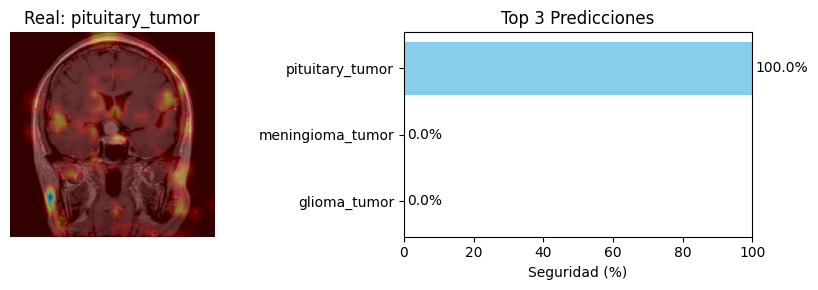

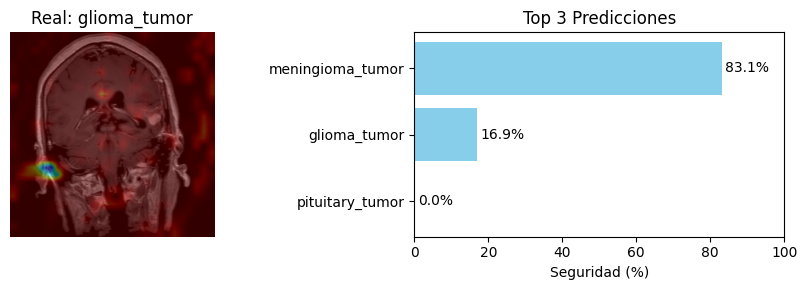

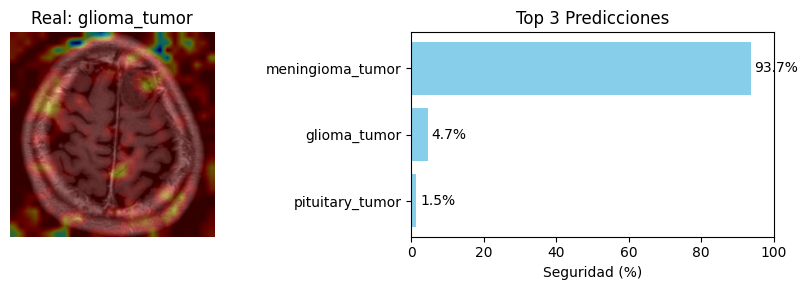

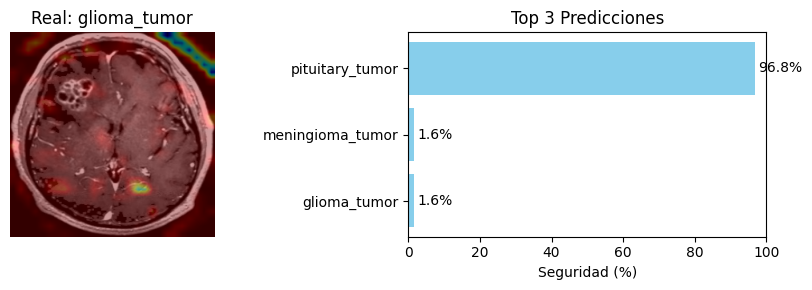

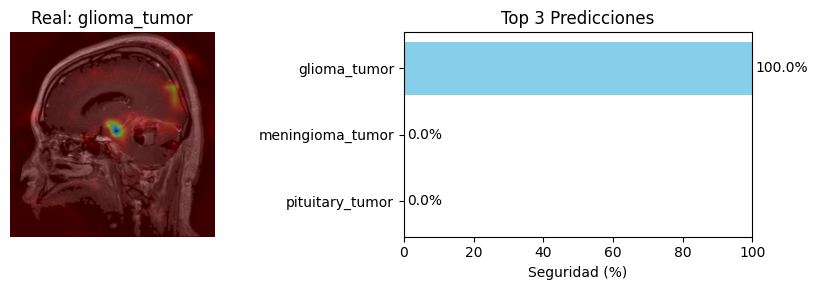

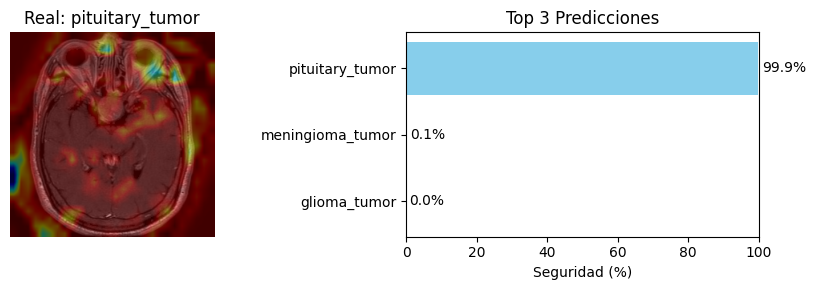

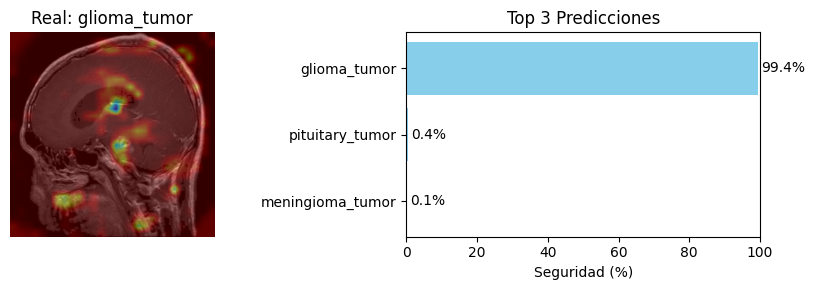

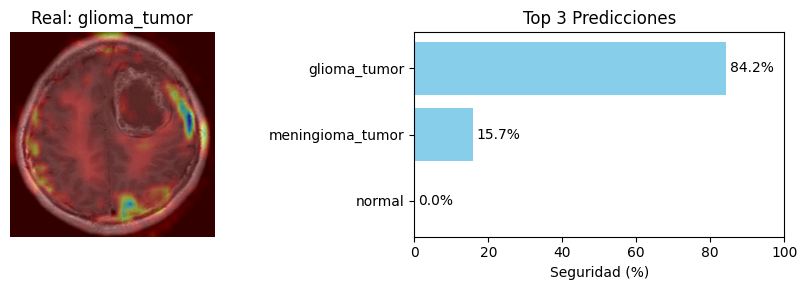

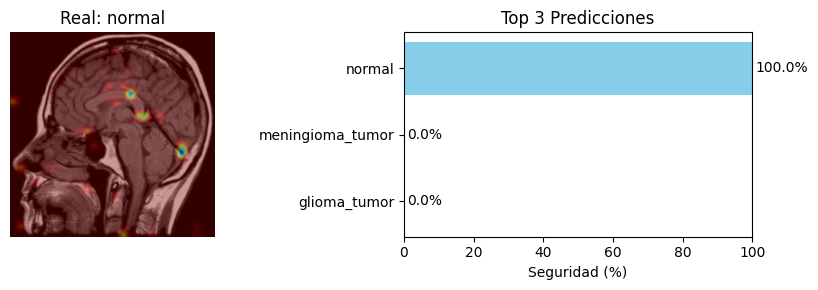

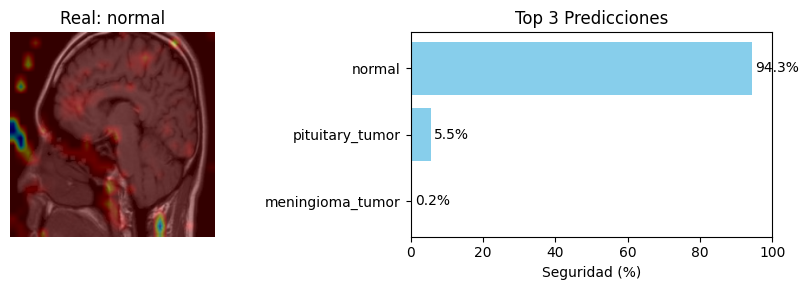

In [116]:
import matplotlib.pyplot as plt
import cv2

def display_gradcam_results(dataset, model, last_conv_layer_name, num_images=5):
    for i, (img, label) in enumerate(dataset.unbatch().shuffle(buffer_size=1000, seed=random_state).take(num_images)):
        img_tensor = np.expand_dims(img, axis=0)
        preds = model.predict(img_tensor, verbose=0)[0]
        top_3_idx = np.argsort(preds)[-3:][::-1]
        heatmap = get_gradcam_heatmap(img_tensor, model, last_conv_layer_name)
        img_np = img.numpy().astype("uint8")
        heatmap_resized = cv2.resize(heatmap, (256, 256))
    
        heatmap_color = np.uint8(255 * heatmap_resized)
        heatmap_color = cv2.applyColorMap(heatmap_color, cv2.COLORMAP_JET)
        superimposed_img = cv2.addWeighted(img_np, 0.6, heatmap_color, 0.4, 0)
        
        plt.figure(figsize=(9, 3))
        plt.subplot(1, 2, 1)
        plt.imshow(superimposed_img)
        plt.title(f"Real: {class_names[label.numpy()]}")
        plt.axis('off')
        plt.subplot(1, 2, 2)
        top_names = [class_names[idx] for idx in top_3_idx]
        top_scores = [preds[idx] * 100 for idx in top_3_idx]
        bars = plt.barh(top_names, top_scores, color='skyblue')
        plt.xlabel('Seguridad (%)')
        plt.title('Top 3 Predicciones')
        plt.xlim(0, 100)
        plt.gca().invert_yaxis()
        
        for bar in bars:
            plt.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, 
                     f'{bar.get_width():.1f}%', va='center')

        plt.tight_layout()
        plt.show()

display_gradcam_results(ds_test, model, "conv2d_37", num_images=10)

A pesar de los buenos resultados obtenidos, en las imágenes se puede apreciar que la red no es muy precisa a la hora de enfocar las zonas afectadas en el cerebro. Esto seguramente se deba porque el modelo no es lo suficientemente complejo para identificar correctamente los patrones de la imagen.

Asimismo, la incorporación de un mapa de calor y del ranking de clasificación de clases hace que los expertos puedan interpretar mejor los resultados.

### 3.2 CNN con Transfer Learning

Esta técnica se suele utilizar cuando no se tienen los suficientes recursos para entrenar un modelo desde 0. Se hace uso de un modelo pre-entrenado que se utilizó para resolver un problema similar, y se descongelan algunas capas para adaptarlas al nuevo problema. Se ha elegido **EfficientNetV2M** como función de transfer learning, debido a que se especializa en la clasificación de imágenes, y según las pruebas realizadas en ImageNet, tiene en **Top1 un 85.3% de accuracy**, que es de los más altos dentro de la categoría de EfficientNet.
- **Técnica para combatir el sobreajuste:** Haremos uso de **Dropout**, la cual ha sido explicada anteriormente.
- **Técnica para que el modelo se adapte mejor al problema en cuestión:** Se ha descongelado la primera capa para que el modelo se adapte mejor al problema que estamos tratando, pues nos permitirá identificar mejor las características más básicas de las imágenes a clasificar.
- **Técnica para prevenir el sobreajuste:** La técnica que se ha utilizado es el aumento de datos utilizando un generador de flujo: **ImageDataGenerator**.

In [117]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
train_datagen = ImageDataGenerator(
    rotation_range = 0.1,
    shear_range=0.2,
    zoom_range=0.2
)

In [ ]:
directory = Path(".") / "data" / "train"
batch_size = 32
target_size = (256, 256)
class_mode = "sparse"

train_generator_transfer = train_datagen.flow_from_directory(
    directory,
    batch_size = batch_size,
    target_size = target_size,
    class_mode = class_mode,
    seed = random_state
)

Found 1855 images belonging to 4 classes.


In [119]:
include_top = False
weights = "imagenet"
input_shape = (256, 256, 3)

model_transf = tf.keras.applications.EfficientNetV2M(include_top, weights, input_shape = input_shape)

214201816/214201816 ━━━━━━━━━━━━━━━━━━━━ 16s 0us/step


In [120]:
len(model_transf.layers)

740

In [121]:
fine_tuning = 446
for layer in model_transf.layers[:fine_tuning]:
    layer.trainable = False

model_transf.layers[0].trainable = True # Descongelamos la primera capa

In [122]:
x = model_transf.output
x = keras.layers.Flatten("channels_last")(x)
x = keras.layers.Dropout(0.5)(x)
units = 128
activation = "relu"
x = keras.layers.Dense(units, activation)(x)
x = keras.layers.Dense(units, activation)(x)

units = len(class_names)
activation = "softmax"
x = keras.layers.Dense(units, activation)(x)

In [123]:
inputs = model_transf.input
outputs = x

length = 79

model_transf = keras.Model(inputs, outputs)
model_transf.summary(length)

Model: "functional_240"

┏━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)         ┃ Output Shape       ┃    Param # ┃ Connected to       ┃
┡━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_112      │ (None, 256, 256,   │          0 │ -                  │
│ (InputLayer)         │ 3)                 │            │                    │
├──────────────────────┼────────────────────┼────────────┼────────────────────┤
│ rescaling_8          │ (None, 256, 256,   │          0 │ input_layer_112[0… │
│ (Rescaling)          │ 3)                 │            │                    │
├──────────────────────┼────────────────────┼────────────┼────────────────────┤
│ stem_conv (Conv2D)   │ (None, 128, 128,   │        648 │ rescaling_8[0][0]  │
│                      │ 24)                │            │                    │
├──────────────────────┼────────────────────┼────────────┼────────────────────┤
│ stem_bn              │ (None, 128, 128,   │         96 │ stem_conv[0][0]    │
│ (BatchNormalization) │ 24)                │            │                    │
├──────────────────────┼────────────────────┼────────────┼────────────────────┤
│ stem_activation      │ (None, 128, 128,   │          0 │ stem_bn[0][0]      │
│ (Activation)         │ 24)                │            │                    │
├──────────────────────┼────────────────────┼────────────┼────────────────────┤
│ block1a_project_conv │ (None, 128, 128,   │      5,184 │ stem_activation[0… │
│ (Conv2D)             │ 24)                │            │                    │
├──────────────────────┼────────────────────┼────────────┼────────────────────┤
│ block1a_project_bn   │ (None, 128, 128,   │         96 │ block1a_project_c… │
│ (BatchNormalization) │ 24)                │            │                    │
├──────────────────────┼────────────────────┼────────────┼────────────────────┤
│ block1a_project_act… │ (None, 128, 128,   │          0 │ block1a_project_b… │
│ (Activation)         │ 24)                │            │                    │
├──────────────────────┼────────────────────┼────────────┼────────────────────┤
│ block1a_add (Add)    │ (None, 128, 128,   │          0 │ block1a_project_a… │
│                      │ 24)                │            │ stem_activation[0… │
├──────────────────────┼────────────────────┼────────────┼────────────────────┤
│ block1b_project_conv │ (None, 128, 128,   │      5,184 │ block1a_add[0][0]  │
│ (Conv2D)             │ 24)                │            │                    │
├──────────────────────┼────────────────────┼────────────┼────────────────────┤
│ block1b_project_bn   │ (None, 128, 128,   │         96 │ block1b_project_c… │
│ (BatchNormalization) │ 24)                │            │                    │
├──────────────────────┼────────────────────┼────────────┼────────────────────┤
│ block1b_project_act… │ (None, 128, 128,   │          0 │ block1b_project_b… │
│ (Activation)         │ 24)                │            │                    │
├──────────────────────┼────────────────────┼────────────┼────────────────────┤
│ block1b_drop         │ (None, 128, 128,   │          0 │ block1b_project_a… │
│ (Dropout)            │ 24)                │            │                    │
├──────────────────────┼────────────────────┼────────────┼────────────────────┤
│ block1b_add (Add)    │ (None, 128, 128,   │          0 │ block1b_drop[0][0… │
│                      │ 24)                │            │ block1a_add[0][0]  │
├──────────────────────┼────────────────────┼────────────┼────────────────────┤
│ block1c_project_conv │ (None, 128, 128,   │      5,184 │ block1b_add[0][0]  │
│ (Conv2D)             │ 24)                │            │                    │
├──────────────────────┼────────────────────┼────────────┼────────────────────┤
│ block1c_project_bn   │ (None, 128, 128,   │         96 │ block1c_project_c… │
│ (BatchNormalization) │ 24)                │            │                    │


 Total params: 63,653,304 (242.82 MB)

 Trainable params: 49,467,076 (188.70 MB)

 Non-trainable params: 14,186,228 (54.12 MB)

Como se puede apreciar, esta red es mucho más compleja y completa que la anterior, por lo que es esperan mejores resultados.

In [124]:
lr = 0.001
loss = "sparse_categorical_crossentropy"

optimizer = tf.keras.optimizers.Adam(lr)
metrics = ["accuracy"]

model_transf.compile(optimizer, loss, metrics = metrics)

Se ha establecido un callback adicional llamado EarlyStopping. Esto se debe a que, como los modelos de transfer learning son mucho más complejos, el entrenamiento tarda más que en un modelo simple y, para evitar tiempos de espera muy largos, se establece un criterio de parada temprana en caso de que el modelo deje de mejorar con el paso de las épocas.

In [125]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath="transf_model.keras",
        save_best_only=True,
        monitor="val_loss"),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=20,
        restore_best_weights=True),
        tf.keras.callbacks.CSVLogger("training_log_tf.csv", append=True)
]

In [ ]:
ruta = "./transf_model.keras"
if os.path.exists(ruta):
    print("El modelo entrenado ya existe. Modelo cargado")
    model_transf.load_weights(ruta)
    for x, y in ds_test.take(1):
        _ = model_transf.predict(x, verbose=0)
else:
    history = model_transf.fit(
        x = train_generator_transfer,
        validation_data = ds_validation,
        callbacks=callbacks,
        epochs = 50,
        class_weight=mapped_class_weights)
    
    model_transf.save("transf_model.keras")
    hist_df = pd.DataFrame(history.history) 
    hist_df.to_csv('training_history_tf.csv', index=False)

Epoch 1/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 218s 3s/step - accuracy: 0.6431 - loss: 0.2878 - val_accuracy: 0.7715 - val_loss: 0.7158
Epoch 2/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 172s 3s/step - accuracy: 0.8253 - loss: 0.1096 - val_accuracy: 0.7990 - val_loss: 0.7274
Epoch 3/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 175s 3s/step - accuracy: 0.8755 - loss: 0.0798 - val_accuracy: 0.8493 - val_loss: 0.5552
Epoch 4/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 176s 3s/step - accuracy: 0.8992 - loss: 0.0675 - val_accuracy: 0.8882 - val_loss: 0.2768
Epoch 5/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 195s 3s/step - accuracy: 0.9197 - loss: 0.0525 - val_accuracy: 0.9319 - val_loss: 0.2202
Epoch 6/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 172s 3s/step - accuracy: 0.9256 - loss: 0.0508 - val_accuracy: 0.8865 - val_loss: 0.3696
Epoch 7/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 172s 3s/step - accuracy: 0.9305 - loss: 0.0453 - val_accuracy: 0.8914 - val_loss: 0.5117
Epoch 8/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 171s 3s/step - accuracy: 0.9391 - loss: 0.0430 - val_accuracy: 0.8865 - v

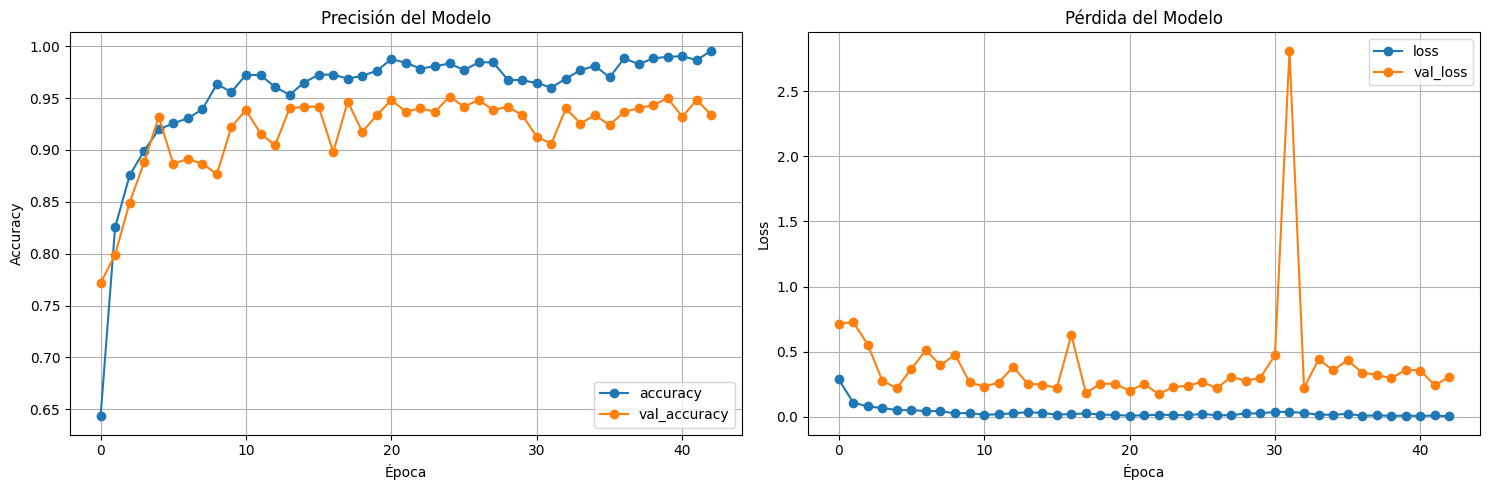

In [128]:
ruta = "./training_history_tf.csv"

if os.path.exists(ruta):
        plot_history_from_csv(ruta)
else:
    print("No se ha guardado historial de datos")

Como se puede apreciar, este modelo sobreajsuta menos y obtiene mejores resultados que la red anterior.

In [131]:
y_true = np.concatenate([y for x, y in ds_test], axis=0)
y_pred_probs = model_transf.predict(ds_test)
y_pred = np.argmax(y_pred_probs, axis=1)

print(classification_report(y_true, y_pred, target_names=class_names))

20/20 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step
                  precision    recall  f1-score   support

    glioma_tumor       0.97      0.91      0.94       181
meningioma_tumor       0.91      0.93      0.92       184
          normal       0.94      0.98      0.96        89
 pituitary_tumor       0.95      0.98      0.96       170

        accuracy                           0.94       624
       macro avg       0.94      0.95      0.94       624
    weighted avg       0.94      0.94      0.94       624



En general, para todas las clases, se mantiene la proporción de los resultados anteriores (p.e, glioma_tummor tiene gran precisión pero menos recall). Sin embargo, la mejora de los resultados es muy notoria, pues se ha resuelto en gran medida el problema del recall de la clase glioma_tumor.

Asimismo, el **accuracy** y el **macro average** de las otras métricas ha subido considerablemente.

In [ ]:
def get_gradcam_plus_transfer(img_array, model, last_conv_layer_name):
    grad_model = tf.keras.Model(
        inputs=model.input,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-10)
    return heatmap.numpy()

def display_gradcam_results_tf(dataset, model, last_conv_layer_name, num_images=5):
    for i, (img, label) in enumerate(dataset.unbatch().shuffle(buffer_size=1000, seed=random_state).take(num_images)):
        img_tensor = np.expand_dims(img, axis=0)
        preds = model.predict(img_tensor, verbose=0)[0]
        top_3_idx = np.argsort(preds)[-3:][::-1]
        heatmap = get_gradcam_plus_transfer(img_tensor, model, last_conv_layer_name)
        img_np = img.numpy().astype("uint8")
        heatmap_resized = cv2.resize(heatmap, (256, 256))
    
        heatmap_color = np.uint8(255 * heatmap_resized)
        heatmap_color = cv2.applyColorMap(heatmap_color, cv2.COLORMAP_JET)
        superimposed_img = cv2.addWeighted(img_np, 0.6, heatmap_color, 0.4, 0)
        
        plt.figure(figsize=(9, 3))
        plt.subplot(1, 2, 1)
        plt.imshow(superimposed_img)
        plt.title(f"Real: {class_names[label.numpy()]}")
        plt.axis('off')
        plt.subplot(1, 2, 2)
        top_names = [class_names[idx] for idx in top_3_idx]
        top_scores = [preds[idx] * 100 for idx in top_3_idx]
        bars = plt.barh(top_names, top_scores, color='skyblue')
        plt.xlabel('Seguridad (%)')
        plt.title('Top 3 Predicciones')
        plt.xlim(0, 100)
        plt.gca().invert_yaxis()
        
        for bar in bars:
            plt.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, 
                     f'{bar.get_width():.1f}%', va='center')

        plt.tight_layout()
        plt.show()

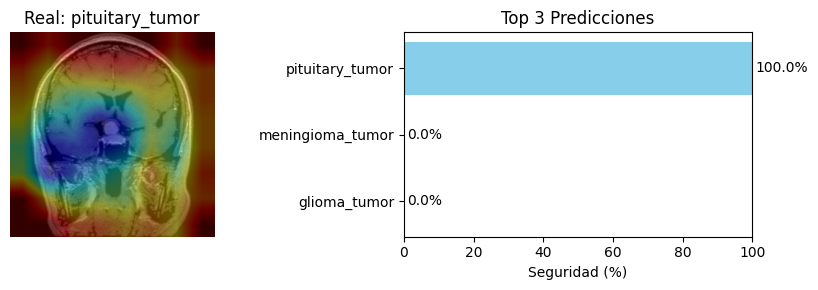

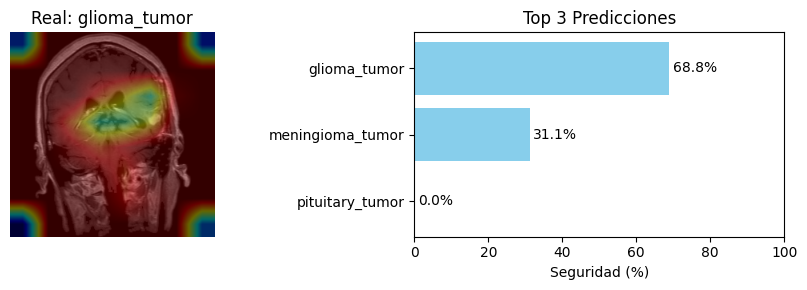

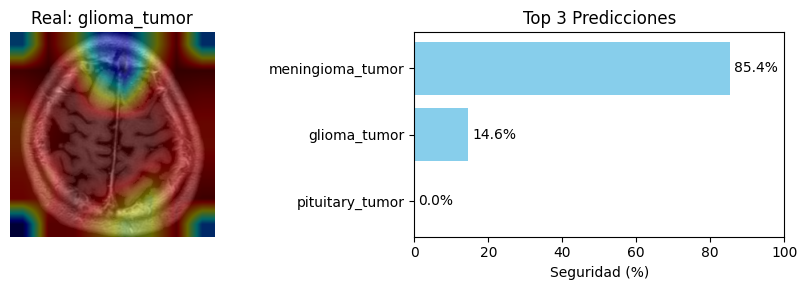

In [138]:
display_gradcam_results_tf(ds_test, model_transf, "top_conv", num_images=3)

Como se puede apreciar en las imágenes, el foco del modelo es mucho más preciso que en la anterior CNN. El mapa de calor muestra que el modelo distingue mejor las regiones importantes de las imágenes, lo cual ha generado un gran avance en la clasificación.

Se puede apreciar que el modelo está siendo efectivamente más preciso, pues en la última imagen de glioma_tumor y la tercera imagen del mapa de calor de la CNN Custom, a pesar de que ambos modelos clasifican mal el tumor, la red creada con transfer learning introduce más porcentaje de clasificación en la clase que realmente se representa en la imagen.